# 03 — Modeling: Baseline, XGBoost, Threshold & Cost Analysis, SHAP

Uses `src/model.py` and `src/scoring.py` directly rather than duplicating logic — this notebook
is the narrative walkthrough, the `.py` modules are the reusable pipeline (also what the
Streamlit dashboard imports).

In [1]:
import sys
sys.path.insert(0, "../src")
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

import model as m
from features import get_model_feature_columns, INTERPRETABLE_MODEL_FEATURES

df = pd.read_parquet("../data/processed/transactions_features.parquet")
train, test = m.chronological_split(df)

Train: 472,432 rows (days 1-141), fraud rate 3.5135%
Test:  118,108 rows (days 141-182), fraud rate 3.4409%


## Why a chronological split?

A fraud model is deployed to score **future** transactions. A random split lets the model
see transactions from the same time window as its test set, which inflates apparent
performance relative to real deployment. Splitting on `TransactionDT` (first 80% -> train,
last 20% -> test) evaluates the model the way it will actually be used.

## Baseline: Logistic Regression (interpretable features only)

In [2]:
logreg_pipe, logreg_proba, logreg_metrics = m.train_baseline_logreg(train, test)
logreg_metrics

[Logistic Regression baseline] ROC-AUC=0.7575  PR-AUC=0.1426


{'roc_auc': np.float64(0.7574713120982175),
 'pr_auc': np.float64(0.14264949123829299)}

## Main model: XGBoost (interpretable + masked features)

In [3]:
feature_cols = get_model_feature_columns(df, include_masked=True)
xgb_model, xgb_proba, xgb_metrics = m.train_xgboost(train, test, feature_cols)
print(f"Logistic Regression -> ROC-AUC {logreg_metrics['roc_auc']:.3f}, PR-AUC {logreg_metrics['pr_auc']:.3f}")
print(f"XGBoost             -> ROC-AUC {xgb_metrics['roc_auc']:.3f}, PR-AUC {xgb_metrics['pr_auc']:.3f}")

[XGBoost] ROC-AUC=0.8911  PR-AUC=0.4881
Logistic Regression -> ROC-AUC 0.757, PR-AUC 0.143
XGBoost             -> ROC-AUC 0.891, PR-AUC 0.488


PR-AUC (precision-recall) matters far more than accuracy or even ROC-AUC here: fraud is ~3.5% of transactions, so a model predicting "never fraud" would score 96.5% accuracy while catching zero fraud.

## Threshold sweep

Default 0.5 is not necessarily the right operating point. Sweeping thresholds shows the alert-volume / precision / recall trade-off directly.

In [4]:
y_test = test["isFraud"].values
sweep = m.threshold_sweep(y_test, xgb_proba)
sweep.round(4)

,threshold,alerts,precision,recall,f1,true_positives,false_positives,false_negatives,true_negatives
0,0.1,71848,0.0539,0.9535,0.1021,3875,67973,189,46071
1,0.2,40346,0.0896,0.8900,0.1629,3617,36729,447,77315
2,0.3,24379,0.1367,0.8201,0.2344,3333,21046,731,92998
3,0.4,16199,0.1892,0.7542,0.3025,3065,13134,999,100910
4,0.5,11106,0.2491,0.6809,0.3648,2767,8339,1297,105705
5,0.6,7545,0.3256,0.6046,0.4233,2457,5088,1607,108956
6,0.7,4820,0.4320,0.5123,0.4687,2082,2738,1982,111306
7,0.8,2948,0.5594,0.4058,0.4703,1649,1299,2415,112745
8,0.9,1530,0.7523,0.2832,0.4115,1151,379,2913,113665


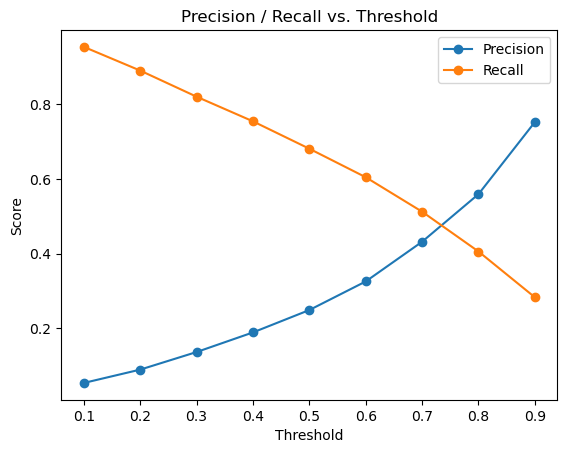

In [5]:
fig, ax = plt.subplots()
ax.plot(sweep["threshold"], sweep["precision"], marker="o", label="Precision")
ax.plot(sweep["threshold"], sweep["recall"], marker="o", label="Recall")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score"); ax.legend(); ax.set_title("Precision / Recall vs. Threshold")
plt.show()

## Fixed investigation capacity: Fraud Capture@500/day

Assume investigators can only review 500 alerts per day. How much fraud gets caught?

In [6]:
cap500 = m.capacity_at_k(y_test, xgb_proba, k=500)
print("Single global top-500 cut:", cap500)

daily = m.daily_capacity_simulation(test, xgb_proba, capacity=500)
print(f"\nAveraged daily recall at 500/day capacity: {daily['recall'].mean():.1%}")
daily.head()

Single global top-500 cut: {'k': 500, 'fraud_captured': 469, 'fraud_total': 4064, 'precision_at_k': 0.938, 'recall_at_k': 0.11540354330708662}

Averaged daily recall at 500/day capacity: 79.3%


,day,transactions,fraud_in_day,alerts_reviewed,fraud_captured,precision,recall
0,141,2574,122,500,97,0.194,0.795082
1,142,2391,103,500,89,0.178,0.864078
2,143,2064,71,500,63,0.126,0.887324
3,144,2718,90,500,72,0.144,0.800000
4,145,2668,67,500,55,0.110,0.820896


## Cost-sensitive threshold optimization

**Scenario assumptions, not real industry costs:** false negative = \$500, false positive review = \$10.

threshold               0.240000
alerts              32545.000000
precision               0.107881
recall                  0.863927
f1                      0.191811
true_positives       3511.000000
false_positives     29034.000000
false_negatives       553.000000
true_negatives      85010.000000
total_cost         566840.000000
Name: 11, dtype: float64


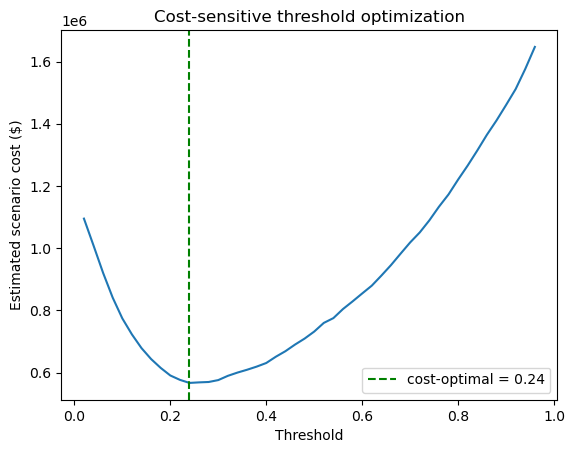

In [7]:
cost_curve = m.cost_sensitive_threshold(y_test, xgb_proba)
best = cost_curve.loc[cost_curve["total_cost"].idxmin()]
print(best)

fig, ax = plt.subplots()
ax.plot(cost_curve["threshold"], cost_curve["total_cost"])
ax.axvline(best["threshold"], color="green", linestyle="--", label=f"cost-optimal = {best['threshold']:.2f}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Estimated scenario cost ($)"); ax.legend()
ax.set_title("Cost-sensitive threshold optimization")
plt.show()

## SHAP: global feature importance

Computed on a 20k sample of the test set for speed. Masked (`C/D/M/V/id_`) features are labeled generically — no invented per-column meaning.

In [8]:
explainer, shap_values, X_sample = m.compute_shap(xgb_model, test[feature_cols], sample_size=20000)
importance = m.global_feature_importance(shap_values, feature_cols)
importance.head(20)

,feature,mean_abs_shap
0,P_emaildomain,0.181390
1,C14,0.178524
2,C13,0.176623
3,card6,0.172652
4,TransactionAmt,0.166162
5,C1,0.151947
6,V70,0.133417
7,C11,0.131704
8,R_emaildomain,0.124567
9,card_avg_amount_prior,0.119202


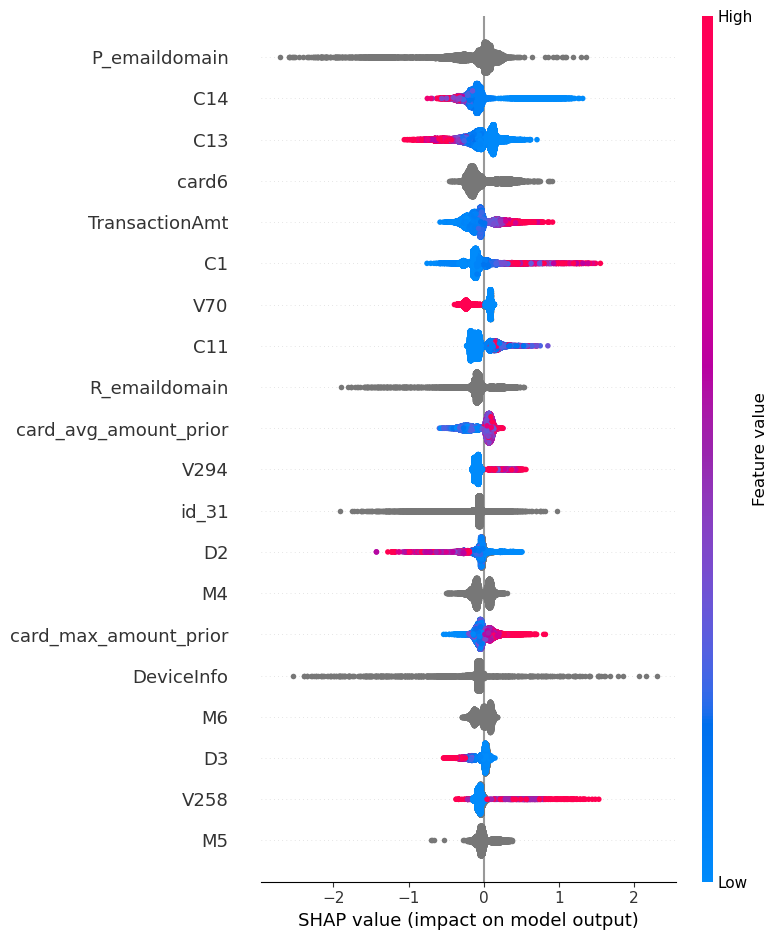

In [9]:
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.tight_layout()
plt.savefig("../outputs/shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()

## Local explanation: one flagged transaction

TransactionID 3492819, fraud_probability=0.9996, isFraud=1


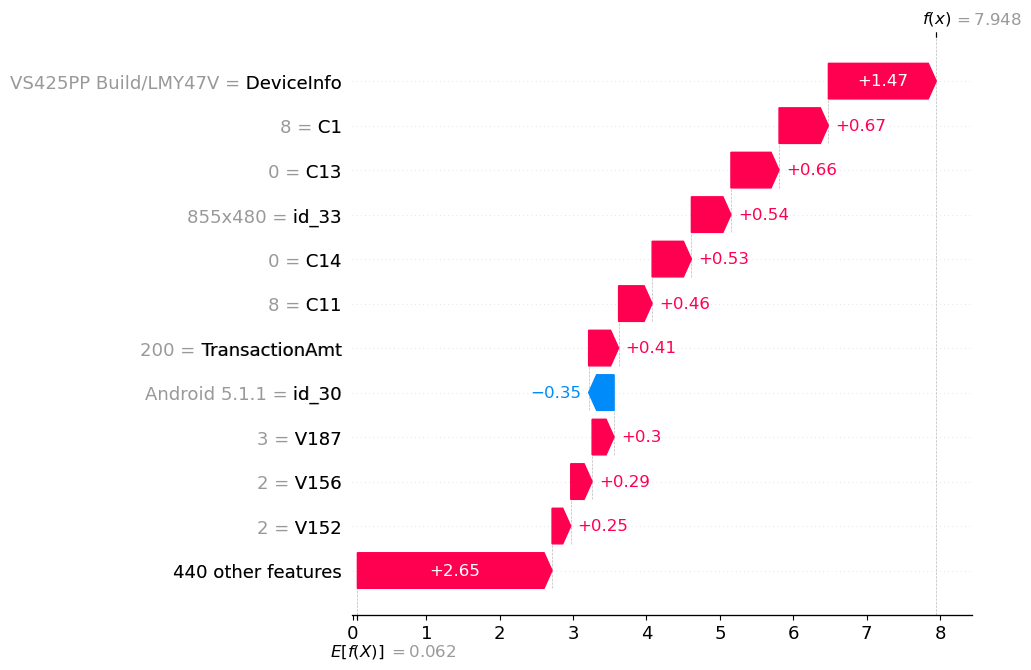

In [10]:
top_idx = np.argsort(-xgb_proba)[0]
row_id = test.iloc[top_idx]["TransactionID"]
print(f"TransactionID {row_id}, fraud_probability={xgb_proba[top_idx]:.4f}, isFraud={test.iloc[top_idx]['isFraud']}")

x_row = test.iloc[[top_idx]][feature_cols]
sv_row = explainer(x_row)
shap.plots.waterfall(sv_row[0], max_display=12, show=True)

## Summary

This notebook produces the same artifacts as `python src/model.py` + `python src/scoring.py`
(model bundle, threshold sweep, cost curve, feature importance) — see `outputs/model_summary.json`
for the run this project's README quotes.